In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [7]:
df.drop(columns=['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], inplace=True)

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns   # Only numerica value 
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)   # Fill null numeric value with median

C:\Users\rajja\AppData\Local\Temp\ipykernel_5328\3836498454.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)   # Fill null numeric value with median


In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns   # only categorical value
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)   #Fill nul categorical  value with mode 

C:\Users\rajja\AppData\Local\Temp\ipykernel_5328\3410311383.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)   #Fill nul categorical  value with mode


In [10]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

In [11]:
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF','1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd']  #Only useful features 

In [12]:
X = df[features]
y = df['SalePrice']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)   # Test train split for better result

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
rf_model = RandomForestRegressor(n_estimators=100,max_depth=20,min_samples_split=5,min_samples_leaf=2,random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)
lr_train_mae = mean_absolute_error(y_train, lr_pred_train)
lr_test_mae = mean_absolute_error(y_test, lr_pred_test)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_pred_train))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_train_r2 = r2_score(y_train, lr_pred_train)
lr_test_r2 = r2_score(y_test, lr_pred_test)

In [17]:
print(f'\nTraining Metrics:')
print(f'  MAE: ${lr_train_mae:,.2f}')
print(f'  RMSE: ${lr_train_rmse:,.2f}')
print(f'  R² Score: {lr_train_r2:.4f}')
print(f'\nTesting Metrics:')
print(f'  MAE: ${lr_test_mae:,.2f}')
print(f'  RMSE: ${lr_test_rmse:,.2f}')
print(f'  R² Score: {lr_test_r2:.4f}')


Training Metrics:
  MAE: $23,760.21
  RMSE: $37,483.11
  R² Score: 0.7644

Testing Metrics:
  MAE: $24,949.12
  RMSE: $39,502.52
  R² Score: 0.7966


In [18]:
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
rf_train_mae = mean_absolute_error(y_train, rf_pred_train)
rf_test_mae = mean_absolute_error(y_test, rf_pred_test)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_pred_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_train_r2 = r2_score(y_train, rf_pred_train)
rf_test_r2 = r2_score(y_test, rf_pred_test)

In [19]:
print(f'\nTraining Metrics:')
print(f'  MAE: ${rf_train_mae:,.2f}')
print(f'  RMSE: ${rf_train_rmse:,.2f}')
print(f'  R² Score: {rf_train_r2:.4f}')
print(f'\nTesting Metrics:')
print(f'  MAE: ${rf_test_mae:,.2f}')
print(f'  RMSE: ${rf_test_rmse:,.2f}')
print(f'  R² Score: {rf_test_r2:.4f}')


Training Metrics:
  MAE: $10,357.48
  RMSE: $17,451.57
  R² Score: 0.9489

Testing Metrics:
  MAE: $19,322.04
  RMSE: $30,429.86
  R² Score: 0.8793


In [20]:
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression (Test)': [f'${lr_test_mae:,.0f}', f'${lr_test_rmse:,.0f}', f'{lr_test_r2:.4f}'],
    'Random Forest (Test)': [f'${rf_test_mae:,.0f}', f'${rf_test_rmse:,.0f}', f'{rf_test_r2:.4f}']
})
print('\n' + comparison.to_string(index=False))


  Metric Linear Regression (Test) Random Forest (Test)
     MAE                  $24,949              $19,322
    RMSE                  $39,503              $30,430
R² Score                   0.7966               0.8793


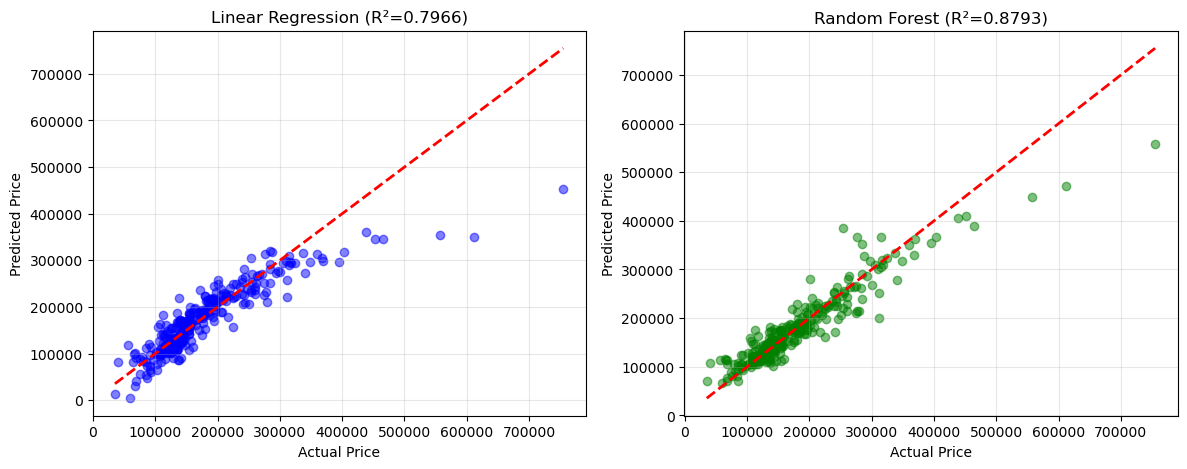

In [21]:
fig, axes = plt.subplots(1,2,  figsize=(14, 5))
axes[0].scatter(y_test, lr_pred_test, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Linear Regression (R²={lr_test_r2:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, rf_pred_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Random Forest (R²={rf_test_r2:.4f})')
axes[1].grid(True, alpha=0.3)

In [22]:
new_house = pd.DataFrame({
    'OverallQual': [8],
    'GrLivArea': [2500],
    'GarageCars': [2],
    'TotalBsmtSF': [1500],
    '1stFlrSF': [2000],
    'FullBath': [2],
    'YearBuilt': [2010],
    'YearRemodAdd': [2015]
})

In [23]:
lr_model.predict(new_house)

array([306063.45564461])

In [24]:
rf_model.predict(new_house)

array([366141.92926984])

In [25]:
if rf_test_r2 > lr_test_r2:
    better_model = "Random Forest"
    better_score = rf_test_r2
else:
    better_model = 'Linear Regression'
    better_score = lr_test_r2
    
print(f"The best model is {better_model} with an R2 of {better_score:.2f}")

The best model is Random Forest with an R2 of 0.88


In [26]:
if better_score > 0.7:
    reliability = 'Excellent'
elif better_score > 0.5:
    reliability = 'Good'
else:
    reliability = 'Moderate'
print(f'Reliability: {reliability}')

Reliability: Excellent
